# Drug Normalization Validation

Coverage rates, method breakdown, top unmatched names, TA cross-tab, and spot checks.

**Depends on**: `run_normalize_drugs.py` (builds `ref.drug_dictionary` and `norm.study_drugs`)

In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

conn = duckdb.connect("../data/clinical_trials.duckdb", read_only=True)
pd.set_option("display.max_colwidth", 80)
pd.set_option("display.max_rows", 50)

## 1. Coverage Summary

In [2]:
# Phase 7B: norm.study_drugs now keys on drug_id (FK → entities.drug)
# instead of canonical_name/canonical_id strings.
total = conn.execute("SELECT COUNT(*) FROM norm.study_drugs").fetchone()[0]
matched = conn.execute("SELECT COUNT(*) FROM norm.study_drugs WHERE drug_id IS NOT NULL").fetchone()[0]
total_studies = conn.execute("SELECT COUNT(DISTINCT nct_id) FROM norm.study_drugs").fetchone()[0]
matched_studies = conn.execute("SELECT COUNT(DISTINCT nct_id) FROM norm.study_drugs WHERE drug_id IS NOT NULL").fetchone()[0]

print(f"Intervention coverage: {matched:,}/{total:,} ({100*matched/total:.1f}%)")
print(f"Study coverage: {matched_studies:,}/{total_studies:,} ({100*matched_studies/total_studies:.1f}%)")

Intervention coverage: 282,707/454,748 (62.2%)
Study coverage: 157,431/231,209 (68.1%)


In [3]:
breakdown = conn.execute("""
    SELECT mapping_method, COUNT(*) as interventions, COUNT(DISTINCT nct_id) as studies
    FROM norm.study_drugs
    GROUP BY mapping_method
    ORDER BY interventions DESC
""").fetchdf()
breakdown

,mapping_method,interventions,studies
0,unmatched,172041,118697
1,mesh-exact,171065,106642
2,chembl-synonym,58962,48708
3,control-map,52680,47747


In [4]:
dict_stats = conn.execute("""
    SELECT mapping_method, confidence, COUNT(*) as entries
    FROM ref.drug_dictionary
    GROUP BY mapping_method, confidence
    ORDER BY entries DESC
""").fetchdf()
print(f"Drug dictionary: {dict_stats['entries'].sum():,} total entries")
dict_stats

Drug dictionary: 23,691 total entries


,mapping_method,confidence,entries
0,chembl-synonym,high,9597
1,control-map,high,8792
2,mesh-exact,high,5302


## 2. Top Unmatched Drug Names

These are targets for manual curation or V2 normalization (DrugBank, RxNorm).

In [5]:
unmatched = conn.execute("""
    SELECT intervention_name, COUNT(DISTINCT nct_id) as studies
    FROM norm.study_drugs
    WHERE drug_id IS NULL
    GROUP BY intervention_name
    ORDER BY studies DESC
    LIMIT 30
""").fetchdf()
unmatched

,intervention_name,studies
0,Chemotherapy,451
1,Nab-paclitaxel,268
2,G-CSF,198
3,S-1,134
4,chemotherapy,116
5,anti-thymocyte globulin,115
6,Nab paclitaxel,114
7,N-acetylcysteine,106
8,Blood sample,103
9,nab-paclitaxel,102


## 3. Most Common Canonical Drugs

In [6]:
top_drugs = conn.execute("""
    SELECT e.canonical_name, COUNT(DISTINCT sd.nct_id) as studies, sd.mapping_method
    FROM norm.study_drugs sd
    JOIN entities.drug e ON sd.drug_id = e.drug_id
    GROUP BY e.canonical_name, sd.mapping_method
    ORDER BY studies DESC
    LIMIT 25
""").fetchdf()
top_drugs

,canonical_name,studies,mapping_method
0,Placebo,41665,control-map
1,Saline,3815,control-map
2,Cyclophosphamide,3050,mesh-exact
3,Cisplatin,2385,mesh-exact
4,Carboplatin,2345,mesh-exact
5,Dexamethasone,2299,mesh-exact
6,Paclitaxel,2224,mesh-exact
7,pembrolizumab,2044,mesh-exact
8,Bevacizumab,1803,mesh-exact
9,Rituximab,1687,mesh-exact


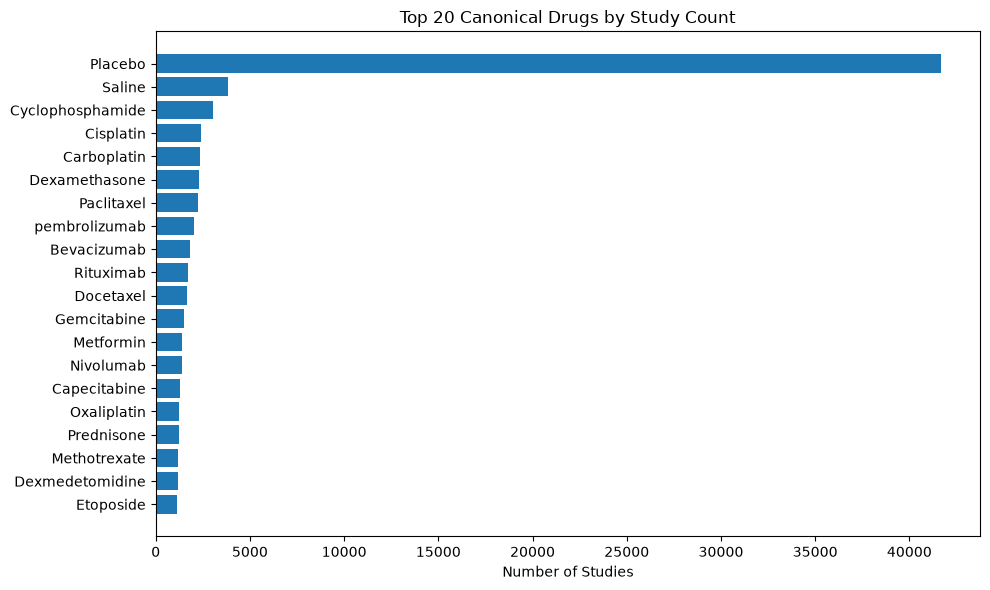

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))
top20 = top_drugs.head(20)
ax.barh(top20["canonical_name"], top20["studies"])
ax.set_xlabel("Number of Studies")
ax.set_title("Top 20 Canonical Drugs by Study Count")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 4. Coverage by Therapeutic Area

In [8]:
ta_cov = conn.execute("""
    SELECT
        ta.therapeutic_area,
        COUNT(DISTINCT sd.nct_id) as drug_studies,
        COUNT(DISTINCT CASE WHEN sd.drug_id IS NOT NULL THEN sd.nct_id END) as mapped_studies,
        ROUND(100.0 * COUNT(DISTINCT CASE WHEN sd.drug_id IS NOT NULL THEN sd.nct_id END)
              / NULLIF(COUNT(DISTINCT sd.nct_id), 0), 1) as coverage_pct
    FROM norm.study_drugs sd
    INNER JOIN norm.study_therapeutic_areas ta ON sd.nct_id = ta.nct_id
    GROUP BY ta.therapeutic_area
    ORDER BY drug_studies DESC
""").fetchdf()
ta_cov

,therapeutic_area,drug_studies,mapped_studies,coverage_pct
0,Oncology,60274,42171,70.0
1,General/Symptoms,46623,33542,71.9
2,Immunology,28361,19990,70.5
3,Metabolic/Endocrine,25392,18583,73.2
4,Infectious Disease,24551,14129,57.5
5,Respiratory,23441,15533,66.3
6,Neurology,23291,16738,71.9
7,Gastroenterology,21920,14591,66.6
8,Dermatology/Rheumatology,20222,14480,71.6
9,Hematology,20126,14221,70.7


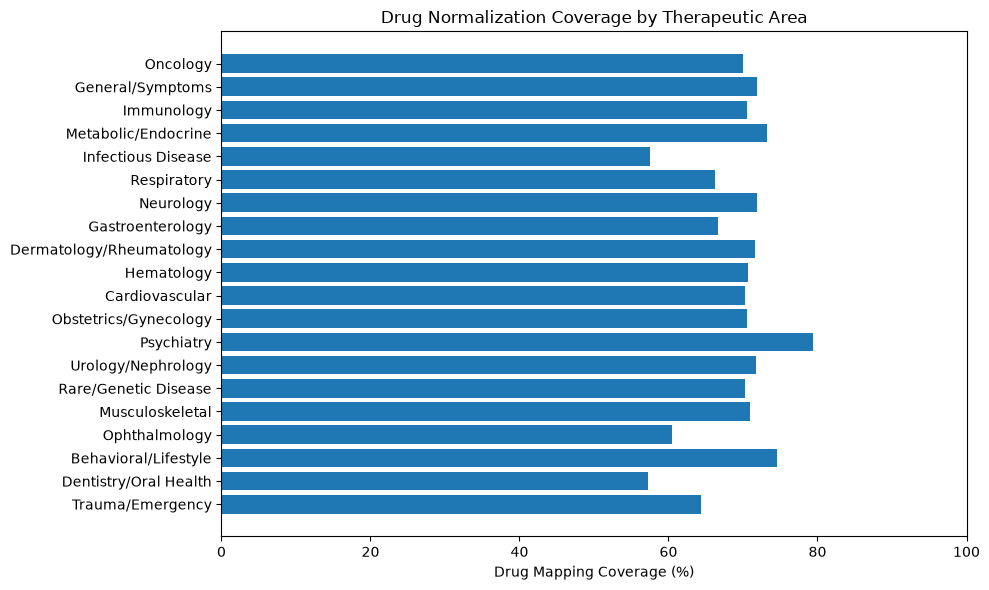

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(ta_cov["therapeutic_area"], ta_cov["coverage_pct"])
ax.set_xlabel("Drug Mapping Coverage (%)")
ax.set_title("Drug Normalization Coverage by Therapeutic Area")
ax.set_xlim(0, 100)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 5. Spot Checks

Sample matched entries to verify quality.

In [10]:
print("=== MeSH exact matches (sample) ===")
display(conn.execute("""
    SELECT sd.intervention_name, e.canonical_name, sd.mapping_method
    FROM norm.study_drugs sd
    JOIN entities.drug e ON sd.drug_id = e.drug_id
    WHERE sd.mapping_method = 'mesh-exact'
    ORDER BY random()
    LIMIT 10
""").fetchdf())

=== MeSH exact matches (sample) ===


,intervention_name,canonical_name,mapping_method
0,Epinastine nasal,epinastine,mesh-exact
1,Dinitrochlorobenzene,Dinitrochlorobenzene,mesh-exact
2,Pomalidomide (CC-4047),pomalidomide,mesh-exact
3,Infliximab,Infliximab,mesh-exact
4,Pregabalin,Pregabalin,mesh-exact
5,furosemide,Furosemide,mesh-exact
6,Leuprolide(Lorelin Depot),Leuprolide,mesh-exact
7,Crizotinib,Crizotinib,mesh-exact
8,Docetaxel,Docetaxel,mesh-exact
9,Intravenous dexamethasone,Dexamethasone,mesh-exact


In [11]:
print("=== ChEMBL synonym matches (sample) ===")
display(conn.execute("""
    SELECT sd.intervention_name, e.canonical_name, e.chembl_id, sd.mapping_method
    FROM norm.study_drugs sd
    JOIN entities.drug e ON sd.drug_id = e.drug_id
    WHERE sd.mapping_method = 'chembl-synonym'
    ORDER BY random()
    LIMIT 10
""").fetchdf())

=== ChEMBL synonym matches (sample) ===


,intervention_name,canonical_name,chembl_id,mapping_method
0,Albumin,ALBUMIN HUMAN,CHEMBL1201451,chembl-synonym
1,GDC-8264,FLIZASERTIB,CHEMBL5314462,chembl-synonym
2,Mitiglinide calcium hydrate,MITIGLINIDE CALCIUM DIHYDRATE,CHEMBL4298005,chembl-synonym
3,Irinotecan Hydrochloride,IRINOTECAN HYDROCHLORIDE,CHEMBL3989514,chembl-synonym
4,Phenobarbital Sodium Injection,PHENOBARBITAL SODIUM,CHEMBL149972,chembl-synonym
5,isosulfan blue,ISOSULFAN BLUE,CHEMBL1200859,chembl-synonym
6,Topotecan Hydrochloride,TOPOTECAN HYDROCHLORIDE,CHEMBL1607,chembl-synonym
7,Chidamide,TUCIDINOSTAT,CHEMBL3621988,chembl-synonym
8,Tarcocimab,TARCOCIMAB,CHEMBL5314617,chembl-synonym
9,Pulmicort,BUDESONIDE,CHEMBL1370,chembl-synonym


In [12]:
print("=== Control/comparator mappings (sample) ===")
display(conn.execute("""
    SELECT sd.intervention_name, e.canonical_name, sd.mapping_method
    FROM norm.study_drugs sd
    JOIN entities.drug e ON sd.drug_id = e.drug_id
    WHERE sd.mapping_method = 'control-map'
    ORDER BY random()
    LIMIT 10
""").fetchdf())

=== Control/comparator mappings (sample) ===


,intervention_name,canonical_name,mapping_method
0,Placebo,Placebo,control-map
1,Matching placebo,Placebo,control-map
2,Placebo,Placebo,control-map
3,Standard of care,Standard of Care,control-map
4,Placebo oral tablet,Placebo,control-map
5,Placebo,Placebo,control-map
6,Placebo/sugar pill,Placebo,control-map
7,Placebo,Placebo,control-map
8,Placebo,Placebo,control-map
9,Placebo,Placebo,control-map


In [13]:
print("=== Drugs with multiple intervention name variants ===")
display(conn.execute("""
    SELECT e.canonical_name, COUNT(DISTINCT sd.intervention_name) as variants,
           STRING_AGG(DISTINCT sd.intervention_name, ' | ' ORDER BY sd.intervention_name) as sample_names
    FROM norm.study_drugs sd
    JOIN entities.drug e ON sd.drug_id = e.drug_id
    GROUP BY e.canonical_name
    HAVING COUNT(DISTINCT sd.intervention_name) >= 3
    ORDER BY variants DESC
    LIMIT 15
""").fetchdf())

=== Drugs with multiple intervention name variants ===


,canonical_name,variants,sample_names
0,Placebo,9337,"""Mesalamine"" and ""Placebo"" | ""Placebo"" | (Part C) Placebo | (vs.) Placebo + ..."
1,Saline,1140,"""Drug/Placebo: 0.9% Normal Saline"" | ""Ketamine"" and ""dexmedetomidine"" and ""p..."
2,Vehicle,481,0.3%/1% vehicle gel only | 10XB-101 Vehicle Solution for Injection | 14-Day ...
3,Standard of Care,374,"""Usual Care"" | 0.75% MDI-1228_mesylate gel plus Standard of Care | 2% Chloro..."
4,Sham Comparator,135,4% lidocaine gel application with sham microneedle device | Active bevacizum...
5,Dexamethasone,119,"0,1mg/kg Dexamethasone | 0,2mg/kg Dexamethasone | 0.05mg/kg Dexamethasone | ..."
6,Dexmedetomidine,84,0.05ug/kg Dexmedetomidine | 0.2ug/kg dexmedetomidine | 0.4ug/kg dexmedetomid...
7,Lidocaine,80,10%lidocaine spray | 2%Lidocaine | IV Lidocaine | IV Lidocaine infusion | IV...
8,Tacrolimus,77,Extended Release Tacrolimus Tablets | Extended release tacrolimus | Extended...
9,Metformin,73,1.5g Metformin | 1000 mg metformin | 500 mg metformin | 850 mg metformin | E...


In [14]:
conn.close()